# 04 · LightGBM

Whether a tree earns its place. The bar and the rules were written down in **D-12 before this
model was trained**, and the git history says so: higher PR-AUC on validation, a bootstrap
interval that excludes zero, and a gap big enough to matter operationally. All three, or it
does not win.

> Scored on validation, like everything in S3. Test is read once in B5, with every choice frozen.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from src import config, evaluate, features, train

BLUE, ORANGE = "#2a78d6", "#eb6834"
INK, MUTED, BAND = "#0b0b0b", "#52514e", "#e8e8e6"
plt.rcParams.update(
    {
        "figure.dpi": 130,
        "savefig.dpi": 200,
        "font.size": 9,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.edgecolor": MUTED,
        "axes.labelcolor": INK,
        "text.color": INK,
        "xtick.color": MUTED,
        "ytick.color": MUTED,
        "grid.color": BAND,
        "grid.linewidth": 0.8,
    }
)

matrix = features.load_features()
y_val = matrix.loc[matrix["split"] == "val", "y"].to_numpy()
print(f"{len(y_val):,} validation orders · prevalence {y_val.mean():.2%}")

13,612 validation orders · prevalence 11.86%


## 1 · Every model, one table

The tree is fitted with its rounds chosen on an inner split - the last two months of training -
and then refitted on the whole training block, crises included. Early stopping on validation
would let it choose when to stop by watching the block that judges it.

In [2]:
table = train.model_table("val", matrix)
shown = ["model", "moment", "prevalence", "pr_auc", "recall@10%", "lift@10%", "brier"]
table[shown].round(4)

/home/airuben/projects/ecommerce-review-risk/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_discretization.py:385: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 2 are removed. Consider decreasing the number of bins.
  warnings.warn(
/home/airuben/projects/ecommerce-review-risk/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_discretization.py:385: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 4 are removed. Consider decreasing the number of bins.
  warnings.warn(
/home/airuben/projects/ecommerce-review-risk/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_discretization.py:385: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 5 are removed. Consider decreasing the number of bins.
  warnings.warn(
/home/airuben/projects/ecommerce-review-risk/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_discretization.py:385: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feat

,model,moment,prevalence,pr_auc,recall@10%,lift@10%,brier
0,lightgbm,t0,0.1186,0.2387,0.2441,2.4397,0.1030
1,logistic,t0,0.1186,0.2342,0.2454,2.4521,0.1035
2,logistic binned,t0,0.1186,0.1992,0.2001,2.0001,0.1055
3,single feature,t0,0.1186,0.1645,0.1722,1.7214,NaN
4,constant,t0,0.1186,0.1186,0.0985,0.9846,0.1053
5,lightgbm,t1,0.1186,0.2647,0.2546,2.5450,0.1005
6,logistic,t1,0.1186,0.2572,0.2701,2.6998,0.1008
7,logistic binned,t1,0.1186,0.2113,0.2187,2.1858,0.1038
8,single feature,t1,0.1186,0.1788,0.1667,1.6657,NaN
9,constant,t1,0.1186,0.1186,0.0985,0.9846,0.1053


## 2 · The three criteria, checked one by one

Note what the table already shows: LightGBM is ahead on PR-AUC and **behind on recall@10%**.
PR-AUC integrates the whole curve; recall@10% looks only at the head of the ranking, which is
the part anybody would ever act on.

In [3]:
def recall_at_ten(y_true, scores):
    return evaluate.recall_at_k(y_true, scores, 0.10)


rows = []
for moment in ("t0", "t1"):
    tree = train.model_scores("lightgbm", moment, matrix, "val")
    linear = train.model_scores("logistic", moment, matrix, "val")
    for label, metric in [("pr_auc", evaluate.pr_auc), ("recall@10%", recall_at_ten)]:
        gap, low, high = evaluate.bootstrap_difference(y_val, tree, linear, metric=metric)
        rows.append(
            {
                "moment": moment,
                "metric": label,
                "lightgbm - logistic": gap,
                "low": low,
                "high": high,
                "excludes zero": "yes" if low > 0 or high < 0 else "no",
            }
        )

pd.DataFrame(rows).round(4)

,moment,metric,lightgbm - logistic,low,high,excludes zero
0,t0,pr_auc,0.0045,-0.0062,0.0145,no
1,t0,recall@10%,-0.0012,-0.0169,0.0131,no
2,t1,pr_auc,0.0076,-0.0040,0.0190,no
3,t1,recall@10%,-0.0155,-0.0313,0.0012,no


## 3 · Why it does not win: the tree overfits from round 25

Early stopping on the inner split settled on 69 trees, which looks suspiciously small. The
obvious suspicion is that the inner split is to blame - it is February and March 2018, the
logistics crisis D-08 deliberately kept inside training, so a regime mismatch could be stopping
the model early.

The curve below rules that out. It deliberately looks at validation, as a diagnostic and not as
a way of choosing anything: PR-AUC peaks around 25 trees and decays from there. The 69 rounds
were not too few, they were already past the peak. Even at the oracle stopping point - chosen by
looking at the very block that judges it, which is cheating - the tree reaches 0.2398 at t0 and
0.2699 at t1, against 0.2342 and 0.2572 for the logistic.

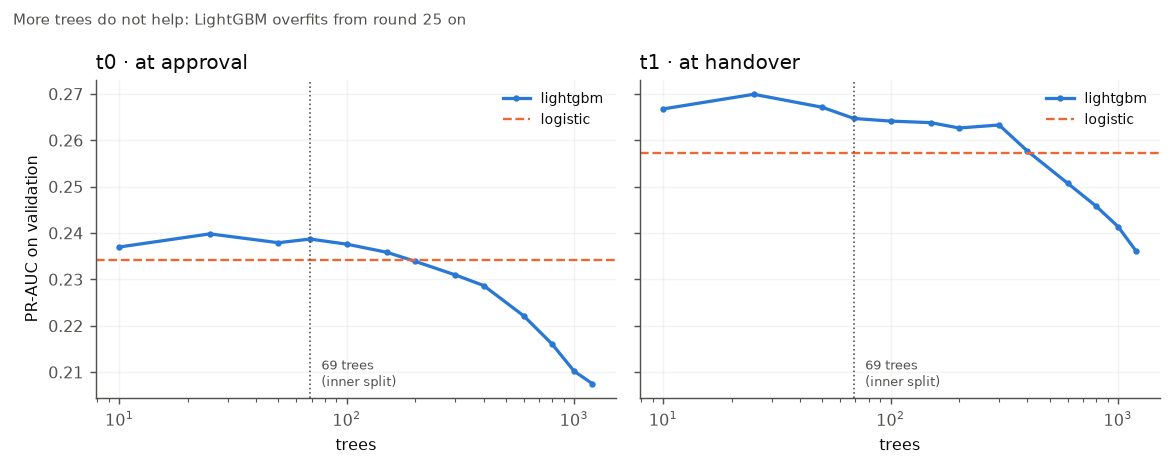

In [4]:
ROUNDS = [10, 25, 50, 69, 100, 150, 200, 300, 400, 600, 800, 1000, 1200]
LOGISTIC = {"t0": 0.2342, "t1": 0.2572}

fig, axes = plt.subplots(1, 2, figsize=(9, 3.6), sharey=True)
importances = {}
for ax, moment in zip(axes, ("t0", "t1"), strict=True):
    columns = features.feature_columns(moment)
    training = matrix[matrix["split"] == "train"]
    model = train.lightgbm_model(max(ROUNDS)).fit(training[columns], training["y"])
    X_val = matrix.loc[matrix["split"] == "val", columns]

    curve = [
        evaluate.pr_auc(y_val, model.predict_proba(X_val, num_iteration=n)[:, 1]) for n in ROUNDS
    ]
    importances[moment] = pd.Series(
        model.booster_.feature_importance("gain"), index=columns
    ).sort_values(ascending=False)

    ax.plot(ROUNDS, curve, color=BLUE, linewidth=1.8, marker="o", markersize=2.5, label="lightgbm")
    ax.axhline(LOGISTIC[moment], color=ORANGE, linewidth=1.3, linestyle="--", label="logistic")
    chosen = train.lightgbm_rounds(moment, matrix)
    ax.axvline(chosen, color=MUTED, linewidth=0.9, linestyle=":")
    ax.text(chosen * 1.12, 0.207, f"{chosen} trees\n(inner split)", color=MUTED, fontsize=7)
    ax.set_xscale("log")
    ax.set_xlabel("trees")
    ax.grid(alpha=0.5)
    ax.set_title(
        f"{moment} · {'at approval' if moment == 't0' else 'at handover'}", loc="left", color=INK
    )
    ax.legend(frameon=False, fontsize=7.5, loc="upper right")

axes[0].set_ylabel("PR-AUC on validation")
fig.suptitle(
    "More trees do not help: LightGBM overfits from round 25 on",
    x=0.005,
    ha="left",
    color=MUTED,
    fontsize=8.5,
)
fig.tight_layout()
fig.savefig(config.FIGURES / "lightgbm_rounds.png", bbox_inches="tight")

## 4 · What the tree leans on

Gain importance: how much each feature improved the loss across every split it was used in.
Read the flatness rather than the order.

In [5]:
shares = pd.DataFrame(
    {moment: (imp / imp.sum()) for moment, imp in importances.items()}
).sort_values("t1", ascending=False)
(shares.head(12) * 100).round(1)

,t0,t1
product_category,7.6,6.7
seller_tenure_days,7.3,6.4
customer_state,7.2,6.3
seller_neg_rate,6.5,5.3
elapsed_share,NaN,5.0
handover_vs_limit_days,NaN,4.9
distance_km,5.7,4.5
approval_latency_h,5.8,4.5
description_len,5.4,4.5
handover_days,NaN,4.3


No feature carries more than 7.6% of the gain. The tree is not finding one dominant rule and
building on it - it is spreading itself thinly across everything, which is the same thing S2 saw
from the other side when no univariate AUC cleared 0.59.

The head of the list matches the logistic's own reading: `seller_neg_rate`, `product_category`,
`customer_state`, distance. Both models agree on where the signal lives. They disagree on
nothing much, which is itself the answer to whether interactions were hiding here.

## 5 · t₀ versus t₁, second opinion

The comparison the project is built on, measured again with a different model class. If the two
disagreed, the conclusion would be a property of the model rather than of the information.

In [6]:
tree_scores = {m: train.model_scores("lightgbm", m, matrix, "val") for m in ("t0", "t1")}
gap, low, high = evaluate.bootstrap_difference(y_val, tree_scores["t1"], tree_scores["t0"])

print(f"lightgbm   t1 - t0 = {gap:+.4f}  [{low:+.4f}, {high:+.4f}]")
print("logistic   t1 - t0 = +0.0230  [+0.0132, +0.0316]   (from 03_baseline)")

lightgbm   t1 - t0 = +0.0260  [+0.0115, +0.0391]
logistic   t1 - t0 = +0.0230  [+0.0132, +0.0316]   (from 03_baseline)


## Verdict

**The logistic stays.** By the rule fixed in D-12 before any of this was run:

| Criterion | Result |
|---|---|
| 1 · Higher PR-AUC on validation | **yes** - +0.0045 at t₀, +0.0076 at t₁ |
| 2 · Bootstrap interval excludes zero | **no** - all four intervals straddle it |
| 3 · Big enough to matter | **no** - recall@10% is *lower*, by 0.1 and 1.6 points |

Criterion 1 alone is the one people quote. It is also the only one the tree passes.

What this says about the data, which is more interesting than which model won: the signal in
these 32 features is **essentially additive**. Binning the features hurt (D-11), so it is not
curvature; a tree free to build any conjunction it likes finds nothing worth 0.01 PR-AUC, so it
is not interactions either. Two independent attempts to find structure beyond a weighted sum,
both empty.

And the two model classes agree on the number the project exists to produce: the handover is
worth about +0.023 to +0.026 PR-AUC over what is known at approval.